# **E-Commerce Product Dataset**

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import os

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

uploded = files.upload()
pd.set_option('display.max_columns', 30)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

df = pd.read_csv("/content/ecommerce_product.csv")

Saving ecommerce_product.csv to ecommerce_product (4).csv


# **Part A — Load, Inspect & Explore**


# **Q1.**
(a) Read ecommerce_product_practice.csv into a DataFrame named df.

(b) Print the number of rows and columns.

(c) Display the first 5 rows and the last 5 rows

In [2]:
print(df.shape)

(80, 12)


In [3]:
df.head()

,product_id,category,brand_type,price,rating,reviews,stock,discount_percent,delivery_days,payment_method,returned,sales_value
0,5001,Beauty,International,"7,065.30",2.90,302.00,148.00,11.20,8.00,Card,No,"36,212.35"
1,5002,Sports,Local,"38,527.38",3.10,291.00,176.00,8.40,6.00,Mobile Banking,No,"32,443.59"
2,5003,Electronics,Local,"23,886.84",4.50,684.00,127.00,23.30,1.00,Mobile Banking,Yes,"122,362.02"
3,5004,Home,International,"26,099.92",4.70,309.00,117.00,37.50,3.00,Cash,No,"148,204.07"
4,5005,Home,Local,NaN,4.80,18.00,17.00,23.00,9.00,Card,No,"373,327.53"


# **Q2**

(a) Print all column names.

(b) Print the data type of every column.

(c) Display the concise DataFrame summary using df.info().

(d) Find the number of missing values in every column

In [4]:
print(df.columns)

Index(['product_id', 'category', 'brand_type', 'price', 'rating', 'reviews',
       'stock', 'discount_percent', 'delivery_days', 'payment_method',
       'returned', 'sales_value'],
      dtype='object')


In [5]:
print(df.dtypes)

product_id            int64
category             object
brand_type           object
price               float64
rating              float64
reviews             float64
stock               float64
discount_percent    float64
delivery_days       float64
payment_method       object
returned             object
sales_value         float64
dtype: object


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_id        80 non-null     int64  
 1   category          78 non-null     object 
 2   brand_type        80 non-null     object 
 3   price             78 non-null     float64
 4   rating            78 non-null     float64
 5   reviews           79 non-null     float64
 6   stock             78 non-null     float64
 7   discount_percent  80 non-null     float64
 8   delivery_days     79 non-null     float64
 9   payment_method    79 non-null     object 
 10  returned          80 non-null     object 
 11  sales_value       80 non-null     float64
dtypes: float64(7), int64(1), object(4)
memory usage: 7.6+ KB


In [7]:
print(df.isnull().sum())

product_id          0
category            2
brand_type          0
price               2
rating              2
reviews             1
stock               2
discount_percent    0
delivery_days       1
payment_method      1
returned            0
sales_value         0
dtype: int64


# **Q3**.

(a) Extract price, rating, and sales_value as NumPy arrays.

(b) Using NumPy, calculate the mean, maximum, minimum, and standard deviation of price.



In [8]:
prices= df[["price","rating","sales_value"]].to_numpy()

print("mean:",np.nanmean(prices))
print("max:",np.nanmax(prices))
print("min:",np.nanmin(prices))
print("std:",np.nanstd(prices))


mean: 39634.3718220339
max: 373327.53
min: 2.0
std: 60539.46323424601


# **Q4**.
(a) Select rows 5–19 and the columns in positions 2, 3, 5, and 10.

(b) Display product_id, category, price, and sales_value for the first 7 products.

In [9]:
print(df.iloc[5:20,[2,3,5,10]])

       brand_type     price  reviews returned
5   International 32,283.21    17.00       No
6           Local 22,081.04   245.00       No
7           Local 23,350.25   369.00       No
8           Local 12,666.92   716.00       No
9   International 13,060.94   247.00      Yes
10          Local  1,442.81   637.00      Yes
11          Local 46,640.53   245.00      Yes
12  International 19,795.27   583.00       No
13  International 32,519.88   362.00       No
14          Local 18,029.95   647.00       No
15  International  5,788.89   842.00       No
16          Local 22,593.34    62.00      Yes
17          Local 23,605.51   124.00       No
18  International  3,189.85   258.00      Yes
19          Local 40,885.20    64.00      Yes


In [10]:
print(df.loc[:7,["product_id","category","price","sales_value"]])

   product_id     category     price  sales_value
0        5001       Beauty  7,065.30    36,212.35
1        5002       Sports 38,527.38    32,443.59
2        5003  Electronics 23,886.84   122,362.02
3        5004         Home 26,099.92   148,204.07
4        5005         Home       NaN   373,327.53
5        5006         Home 32,283.21   249,517.48
6        5007        Books 22,081.04   102,288.42
7        5008       Sports 23,350.25    66,768.37


# **Q5.**

(a) Show all products with price > 30000.

(b) Show products where rating >= 4.5 and stock > 50.

(c) Count products where returned == 'No' and discount_percent > 20.

(d) Use isin() to display products belonging to Electronics or Sports.

In [11]:
productPrice =df[df["price"]>30000]
print(productPrice)


    product_id     category     brand_type     price  rating  reviews  stock  \
1         5002       Sports          Local 38,527.38    3.10   291.00 176.00   
5         5006         Home  International 32,283.21    2.70    17.00   7.00   
11        5012       Sports          Local 46,640.53    2.50   245.00  34.00   
13        5014       Sports  International 32,519.88    2.40   362.00  68.00   
19        5020        Books          Local 40,885.20    4.20    64.00  60.00   
21        5022        Books          Local 32,659.24    2.90   844.00 166.00   
24        5025        Books  International 34,202.78    2.10   746.00  69.00   
25        5026         Home          Local 35,676.44    3.00   499.00 140.00   
26        5027         Home          Local 37,208.05    3.10   599.00 147.00   
29        5030       Beauty          Local 38,322.97    3.90 1,101.00    NaN   
31        5032  Electronics  International 45,643.11    4.20   188.00  85.00   
34        5035         Home          Loc

In [12]:
productStock = df[(df["rating"]>=4.5) & (df["stock"]>50)]
print(productStock)

    product_id     category     brand_type     price  rating  reviews  stock  \
2         5003  Electronics          Local 23,886.84    4.50   684.00 127.00   
3         5004         Home  International 26,099.92    4.70   309.00 117.00   
9         5010       Sports  International 13,060.94    4.80   247.00  83.00   
22        5023         Home  International  7,939.17    4.60   601.00 181.00   
60        5061       Sports          Local    781.29    5.00   811.00  86.00   
61        5062         Home  International 49,119.96    5.00 1,014.00 105.00   
65        5066       Sports  International 17,711.75    5.00 1,186.00 190.00   
70        5071          NaN          Local 47,124.24    4.90   726.00  82.00   
71        5072       Beauty          Local  9,257.95    4.70   573.00  76.00   

    discount_percent  delivery_days  payment_method returned  sales_value  
2              23.30           1.00  Mobile Banking      Yes   122,362.02  
3              37.50           3.00            

In [13]:
productRD = df[(df["returned"] == 'No') & (df["discount_percent"]>20)]
print(productRD)

    product_id     category     brand_type     price  rating  reviews  stock  \
3         5004         Home  International 26,099.92    4.70   309.00 117.00   
4         5005         Home          Local       NaN    4.80    18.00  17.00   
5         5006         Home  International 32,283.21    2.70    17.00   7.00   
6         5007        Books          Local 22,081.04    2.40   245.00 160.00   
7         5008       Sports          Local 23,350.25    4.30   369.00  74.00   
8         5009          NaN          Local 12,666.92    3.00   716.00 162.00   
12        5013       Sports  International 19,795.27     NaN   583.00 155.00   
13        5014       Sports  International 32,519.88    2.40   362.00  68.00   
14        5015       Sports          Local 18,029.95    3.90   647.00 115.00   
15        5016         Home  International  5,788.89    3.40   842.00 116.00   
17        5018         Home          Local 23,605.51    2.30   124.00  42.00   
22        5023         Home  Internation

In [14]:
productCatagory = df[(df["category"].isin(["Electronics","Sports"]))]
print(productCatagory)

    product_id     category     brand_type     price  rating  reviews  stock  \
1         5002       Sports          Local 38,527.38    3.10   291.00 176.00   
2         5003  Electronics          Local 23,886.84    4.50   684.00 127.00   
7         5008       Sports          Local 23,350.25    4.30   369.00  74.00   
9         5010       Sports  International 13,060.94    4.80   247.00  83.00   
11        5012       Sports          Local 46,640.53    2.50   245.00  34.00   
12        5013       Sports  International 19,795.27     NaN   583.00 155.00   
13        5014       Sports  International 32,519.88    2.40   362.00  68.00   
14        5015       Sports          Local 18,029.95    3.90   647.00 115.00   
18        5019       Sports  International  3,189.85    2.30   258.00 189.00   
20        5021  Electronics  International 14,680.26    3.10      NaN 162.00   
30        5031       Sports          Local  2,846.44    2.50   656.00  32.00   
31        5032  Electronics  Internation

# **Part B — IQR, Missing Values, Aggregation & Visualization**

# **Q6.**
Calculate the IQR (Interquartile Range) of price using Q1 and Q3.
Then calculate the lower and upper IQR bounds using:
lower = Q1 - 1.5 × IQR and upper = Q3 + 1.5 × IQR.
Count how many products have prices below the lower bound or above the upper bound.

In [15]:
pricess = df["price"]

Q1 = np.nanpercentile(pricess,25)
Q3 = np.nanpercentile(pricess,75)

IQR = Q3- Q1

lowerbound = Q1-1.5*IQR
upperbound = Q3+1.5*IQR

print("Q1:",Q1)
print("Q3:",Q3)
print("IQR:",IQR)
print("lowerbound:",lowerbound)
print("uppdebound:",upperbound)



Q1: 14564.8725
Q3: 36936.935
IQR: 22372.0625
lowerbound: -18993.221250000002
uppdebound: 70495.02875


# **Q7.**
Create a Boolean condition to identify price outliers using the IQR bounds from Q6.
Display product_id, category, price for all detected price outliers.
Create a new DataFrame named df_no_price_outliers after removing those price outlier rows.

In [16]:
outlier_condition = (df["price"] < lowerbound) | (df["price"] > upperbound)

outliers = df[outlier_condition]

print(outliers[["product_id", "category", "price"]])

df_no_price_outliers = df[~outlier_condition]

Empty DataFrame
Columns: [product_id, category, price]
Index: []


# **Q8.**

(a) Find the average sales_value and average price for each category.

(b) Sort the result from highest average sales_value to lowest.

(c) Count products by category and by payment_method.

In [17]:
avg_sales_price = df.groupby("category")[["sales_value","price"]].mean()
print(avg_sales_price)


             sales_value     price
category                          
Beauty         70,858.09 20,906.28
Books         109,130.81 25,387.03
Electronics    95,760.11 31,061.23
Home          120,822.64 28,502.44
Sports         69,924.36 22,062.65


In [18]:
avg_sales_price = avg_sales_price.sort_values( by="sales_value", ascending=False)
print(avg_sales_price)

             sales_value     price
category                          
Home          120,822.64 28,502.44
Books         109,130.81 25,387.03
Electronics    95,760.11 31,061.23
Beauty         70,858.09 20,906.28
Sports         69,924.36 22,062.65


In [19]:
print("Products by category:")
print(df["category"].value_counts())

print("\nProducts by payment method:")
print(df["payment_method"].value_counts())

Products by category:
category
Sports         21
Home           19
Beauty         15
Electronics    13
Books          10
Name: count, dtype: int64

Products by payment method:
payment_method
Cash              35
Card              27
Mobile Banking    17
Name: count, dtype: int64


# **Q9.**
(a) Draw a bar chart of average sales_value by category.

(b) Draw a histogram of price with 15 bins.

(c) Draw a boxplot of price to visualize possible outliers.

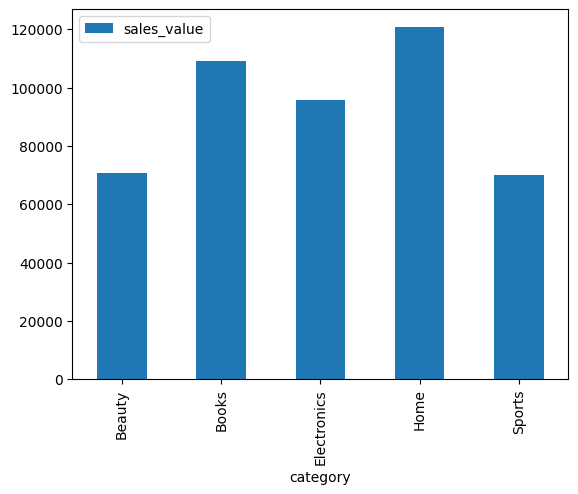

In [20]:
avgsales = df.groupby("category")[["sales_value"]].mean()
avgsales.plot(kind="bar")
plt.show()

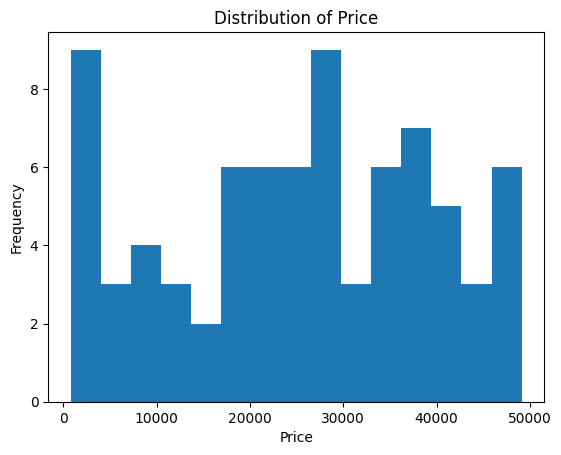

In [21]:
plt.hist(df["price"], bins=15)

plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of Price")

plt.show()

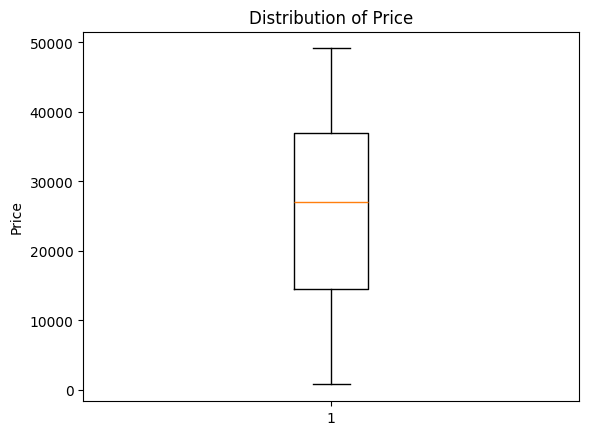

In [22]:
plt.boxplot(df["price"].dropna())

plt.ylabel("Price")
plt.title("Distribution of Price")

plt.show()

# **Part C — Feature Engineering & Data Preparation**

# **Q10.**
Create a new column discount_amount using price × discount_percent / 100.

Create another column discounted_price using price - discount_amount.

Display the first 5 rows with price, discount_percent, discount_amount, discounted_price

In [25]:
df["discountAmount"] = df["price"]*df["discount_percent"]/100
df["discountPrice"] = df["price"]-df["discountAmount"]

print(df[["price","discount_percent","discountAmount","discountPrice"]].head())

      price  discount_percent  discountAmount  discountPrice
0  7,065.30             11.20          791.31       6,273.99
1 38,527.38              8.40        3,236.30      35,291.08
2 23,886.84             23.30        5,565.63      18,321.21
3 26,099.92             37.50        9,787.47      16,312.45
4       NaN             23.00             NaN            NaN


# **Q11.**
 Create a new column stock_status using np.select():

• 'Out of Stock' when stock == 0

• 'Low Stock' when 1 <= stock < 20

• 'Available' otherwise.

Print the counts of each stock_status.

In [36]:
df["stock_status"] = np.select([(df["stock"]==0),(df["stock"]>=1) & (df["stock"]<20)],["Out of Stock","Low Stock"],default="Available")
print(df["stock_status"].value_counts())

stock_status
Available       71
Low Stock        8
Out of Stock     1
Name: count, dtype: int64


# **Q12.**
Create a new column rating_band using np.select():

• 'Excellent' for rating >= 4.5

• 'Good' for 3.5 <= rating < 4.5

• 'Low' otherwise.

Display the first 10 rows of rating and rating_band.

In [40]:
df["rating_band"] = np.select([(df["rating"]>=4.5),((df["rating"]>=3.5) & (df["rating"]<4.5))],["Excellent","Good"],default="Low")
print(df[["rating","rating_band"]].head())

   rating rating_band
0    2.90         Low
1    3.10         Low
2    4.50   Excellent
3    4.70   Excellent
4    4.80   Excellent


# **Part D — Encoding, Scaling, Pipeline & Leakage-Safe Preprocessing**

# **Q13.**
Use sales_value as the target y and use all other useful columns except product_id as features X.
Create X_train, X_test, y_train, y_test using a 75/25 split and random_state=42.
Print the shapes of all four splits.

In [42]:
x=df.drop(columns=["product_id","sales_value"])
y=df["sales_value"]

train_x,test_x,train_y,test_y = train_test_split(x,y,test_size=0.25,random_state=42)

print("X_train shape:",train_x.shape)
print("X_test shape:",test_x.shape)
print("y_train shape:",train_y.shape)
print("y_test shape:",test_y.shape)

X_train shape: (60, 10)
X_test shape: (20, 10)
y_train shape: (60,)
y_test shape: (20,)


# **Q14.**
 For numeric columns with missing values (price, rating, reviews, stock, delivery_days), fill missing
values using the median of each column.
Verify the missing-value count after filling.

In [55]:
numericCol = ["price","rating","reviews","stock","delivery_days"]
imputer = SimpleImputer(strategy="median")

train_x[numericCol] = imputer.fit_transform(train_x[numericCol])
test_x[numericCol] = imputer.transform(test_x[numericCol])

print(train_x[numericCol].isnull().sum())
print(test_x[numericCol].isnull().sum())

price            0
rating           0
reviews          0
stock            0
delivery_days    0
dtype: int64
price            0
rating           0
reviews          0
stock            0
delivery_days    0
dtype: int64


# **Q15.**
Identify the numeric feature columns and categorical feature columns in X.
For the numeric columns with missing values, create a pipeline using:
SimpleImputer(strategy='median') fi StandardScaler()

In [58]:
numeric_columns = x.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = x.select_dtypes(include=["object"]).columns

print("Numeric columns:", numeric_columns)
print("Categorical columns:", categorical_columns)

Numeric columns: Index(['price', 'rating', 'reviews', 'stock', 'discount_percent',
       'delivery_days'],
      dtype='object')
Categorical columns: Index(['category', 'brand_type', 'payment_method', 'returned'], dtype='object')


In [62]:
numCol = Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("sclar",StandardScaler())
])


# **Q16.**
For the categorical columns, create a pipeline using:
SimpleImputer(strategy='most_frequent') fi OneHotEncoder(drop='first', sparse_output=False,
handle_unknown='ignore').

In [83]:
catgCol = Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(drop="first", sparse_output=False,handle_unknown="ignore"))
])

# **Q17.**
Use ColumnTransformer to combine the numeric and categorical pipelines.
Fit the transformer on X_train only, then transform both X_train and X_test.
Print the shapes of the transformed training and testing data.

In [84]:
process = ColumnTransformer([
    ("numarical",numCol, numeric_columns),
    ("catagorical", catgCol,categorical_columns )
])




# **Q18.**
Get the transformed feature names using get_feature_names_out().
Print all transformed column names and the total number of transformed features.

In [85]:
train_xProcess = process.fit_transform(train_x)
test_xProcess = process.transform(test_x)

print("X_train shape:", train_xProcess.shape)
print("X_test shape:", test_xProcess.shape)

process.get_feature_names_out()

X_train shape: (60, 14)
X_test shape: (20, 14)


array(['numarical__price', 'numarical__rating', 'numarical__reviews',
       'numarical__stock', 'numarical__discount_percent',
       'numarical__delivery_days', 'catagorical__category_Books',
       'catagorical__category_Electronics', 'catagorical__category_Home',
       'catagorical__category_Sports', 'catagorical__brand_type_Local',
       'catagorical__payment_method_Cash',
       'catagorical__payment_method_Mobile Banking',
       'catagorical__returned_Yes'], dtype=object)

# **Q19.**
Verify the scaled numeric training features by extracting the numeric transformed part.
Print their mean and standard deviation using NumPy.
The printed numeric means should be approximately 0 and standard deviations approximately 1.

In [86]:
numeric_train = train_xProcess[:, :len(numeric_columns)]

print("Mean:\n", np.mean(numeric_train, axis=0))
print("\nStandard Deviation:\n", np.std(numeric_train, axis=0))

Mean:
 [ 1.73934941e-16  2.84957243e-16  9.99200722e-17 -4.07081776e-17
 -3.70074342e-18 -1.25825276e-16]

Standard Deviation:
 [1. 1. 1. 1. 1. 1.]


# **Q20.**
 Using the original DataFrame, determine which category has the highest average sales_value.
Also calculate the average rating and average discount_percent for that category.

In [90]:
highest_sales = df.groupby("category")["sales_value"].mean().idxmax()
print("Category with the highest average sales value:", highest_sales)

avg_rating = df[df["category"] == highest_sales]["rating"].mean()
avg_discount = df[df["category"] == highest_sales]["discount_percent"]

print("Average rating:", avg_rating)
print("Average discount:", avg_discount)

Category with the highest average sales value: Home
Average rating: 3.5421052631578944
Average discount: 3    37.50
4    23.00
5    26.00
15   46.60
17   25.50
22   33.10
23   32.30
25   11.30
26    7.60
27   28.50
28   20.50
34   46.30
35    5.50
38   19.40
40   21.40
46   42.10
61   14.60
64   49.80
69   12.50
Name: discount_percent, dtype: float64


# **Q21.**
Compare products with discount_percent >= 25 against products with discount_percent < 25.
Calculate the average sales_value for both groups and display the results in a small DataFrame.

In [93]:
high_discount = df[df["discount_percent"] >= 25]["sales_value"].mean()

low_discount = df[df["discount_percent"] < 25]["sales_value"].mean()

result = pd.DataFrame({
    "discount_group": [">= 25%", "< 25%"],
    "average_sales_value": [high_discount, low_discount]
})

print(result)

  discount_group  average_sales_value
0         >= 25%            83,032.35
1          < 25%            99,154.59


# **Q22. Create a final summary table grouped by category containing:**

• product count

• average price

• median rating

• average discount_percent

• average sales_value

Sort the table by average sales_value in descending order

In [94]:
summary = df.groupby("category").agg(
    product_count=("product_id", "count"),
    average_price=("price", "mean"),
    median_rating=("rating", "median"),
    average_discount_percent=("discount_percent", "mean"),
    average_sales_value=("sales_value", "mean")
)

summary = summary.sort_values(
    by="average_sales_value",
    ascending=False
)

print(summary)

             product_count  average_price  median_rating  \
category                                                   
Home                    19      28,502.44           3.40   
Books                   10      25,387.03           3.30   
Electronics             13      31,061.23           3.90   
Beauty                  15      20,906.28           3.80   
Sports                  21      22,062.65           3.10   

             average_discount_percent  average_sales_value  
category                                                    
Home                            26.50           120,822.64  
Books                           22.24           109,130.81  
Electronics                     20.99            95,760.11  
Beauty                          24.51            70,858.09  
Sports                          24.43            69,924.36  
